## Sale Price Prediction Model

### Step 1: import libraries

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#%pip install --force-reinstall "numpy<2" matplotlib seaborn
#%pip install --upgrade --force-reinstall "numpy<2" matplotlib seaborn pandas



In [6]:
# Step 2: Load the dataset

df = pd.read_csv('D:\\Poonam Docs\\Naresh it files\\ML Projects\\Sales_price pridiction\\sales_data.csv')

In [7]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


## Step 2: Data Preprocessing

In [8]:
# check the information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [9]:
# check for missing values
df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [10]:
# drop the Product_ID column
df.drop('Product_ID', axis=1, inplace=True)

In [11]:
# handled the Sale_Date column 

df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

df['Sale_day'] = df['Sale_Date'].dt.day
df['Sale_month'] = df['Sale_Date'].dt.month
df['Sale_year'] = df['Sale_Date'].dt.year



In [12]:
# drop the sale_date column
df.drop('Sale_Date', axis=1, inplace=True)

In [13]:
# drop the Sales_Rep column
df.drop('Sales_Rep', axis=1, inplace=True)

In [14]:
df.head()

,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,Sale_day,Sale_month,Sale_year
0,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob,3,2,2023
1,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob,21,4,2023
2,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David,21,9,2023
3,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob,24,8,2023
4,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie,24,3,2023


In [15]:
# check the describe
df.describe()

,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount,Sale_day,Sale_month,Sale_year
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000
mean,5019.265230,25.355000,2475.304550,2728.440120,0.15239,15.934000,6.50600,2023.003000
std,2846.790126,14.159006,1417.872546,1419.399839,0.08720,8.779677,3.54154,0.054717
min,100.120000,1.000000,60.280000,167.120000,0.00000,1.000000,1.00000,2023.000000
25%,2550.297500,13.000000,1238.380000,1509.085000,0.08000,8.000000,3.00000,2023.000000
50%,5019.300000,25.000000,2467.235000,2696.400000,0.15000,16.000000,6.00000,2023.000000
75%,7507.445000,38.000000,3702.865000,3957.970000,0.23000,24.000000,10.00000,2023.000000
max,9989.040000,49.000000,4995.300000,5442.150000,0.30000,31.000000,12.00000,2024.000000


In [16]:
# check the all categorical columns

categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

Index(['Region', 'Product_Category', 'Customer_Type', 'Payment_Method',
       'Sales_Channel', 'Region_and_Sales_Rep'],
      dtype='object')

In [17]:
# check all categorical columns unique values
for col in categorical_columns:
    print(f"Unique values in column '{col}': {df[col].unique()}")

Unique values in column 'Region': ['North' 'West' 'South' 'East']
Unique values in column 'Product_Category': ['Furniture' 'Food' 'Clothing' 'Electronics']
Unique values in column 'Customer_Type': ['Returning' 'New']
Unique values in column 'Payment_Method': ['Cash' 'Bank Transfer' 'Credit Card']
Unique values in column 'Sales_Channel': ['Online' 'Retail']
Unique values in column 'Region_and_Sales_Rep': ['North-Bob' 'West-Bob' 'South-David' 'South-Bob' 'East-Charlie'
 'West-Charlie' 'South-Eve' 'North-Eve' 'West-Eve' 'South-Alice'
 'South-Charlie' 'North-David' 'East-Bob' 'West-David' 'East-Eve'
 'North-Alice' 'East-David' 'West-Alice' 'East-Alice' 'North-Charlie']


In [18]:
# drop the Region_and_Sales_Rep column
df.drop('Region_and_Sales_Rep', axis=1, inplace=True)

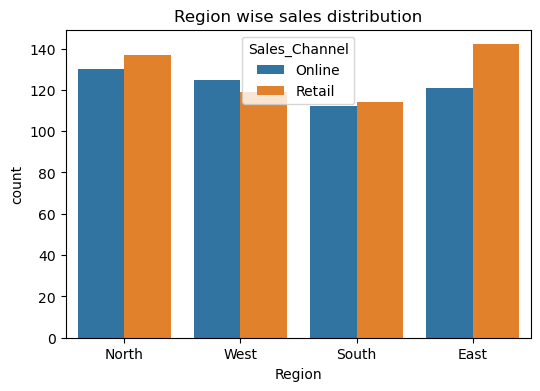

In [19]:
# Step 6: EDA (Exploratory Data Analysis)

# Plot the region wise sales distribution

plt.figure(figsize=(6, 4))

#make countplot for region wise sales distribution
sns.countplot(x='Region',hue='Sales_Channel', data=df)
plt.title('Region wise sales distribution')
plt.show()



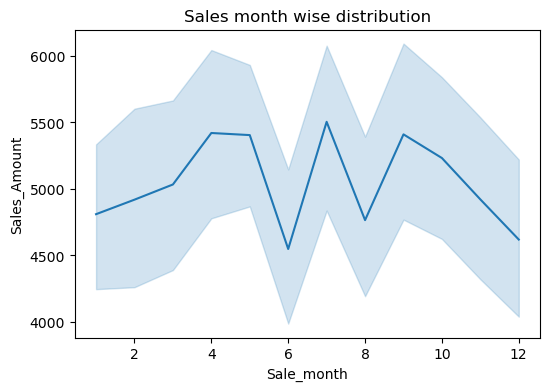

In [20]:
# make the sales year wise distribution
plt.figure(figsize=(6, 4))

#line plot for sales year wise distribution
sns.lineplot(x='Sale_month', y='Sales_Amount', data=df)
plt.title('Sales month wise distribution')
plt.show()

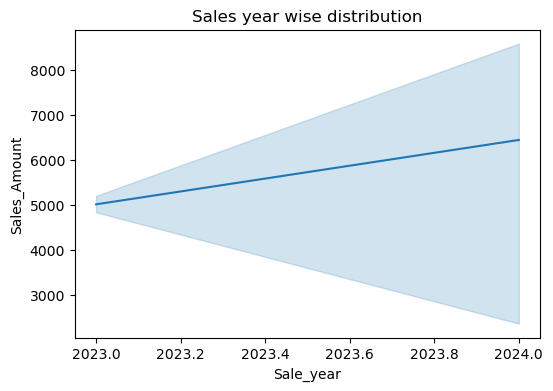

In [21]:
# make the sales month wise distribution
plt.figure(figsize=(6, 4))

#line plot for sales month wise distribution
sns.lineplot(x='Sale_year', y='Sales_Amount', data=df)
plt.title('Sales year wise distribution')
plt.show()

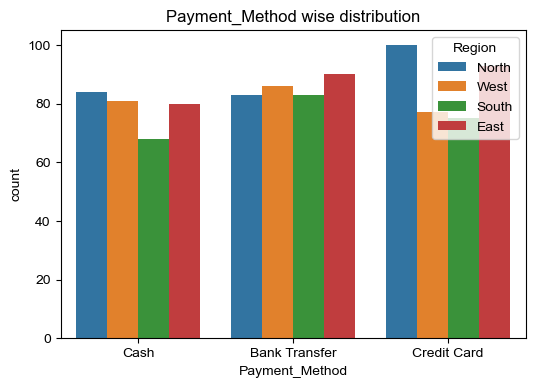

In [22]:
# Make the Payment_Method wise distribution
plt.figure(figsize=(6, 4))

sns.countplot(x='Payment_Method', hue ='Region', data=df)
sns.set_style('whitegrid')
plt.title('Payment_Method wise distribution')
plt.show()

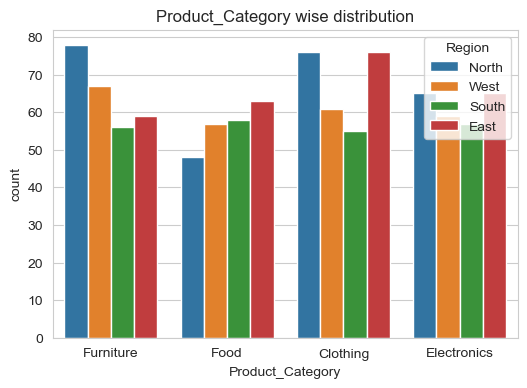

In [23]:
# make the product category  Region wise distribution
plt.figure(figsize=(6, 4))

sns.countplot(x='Product_Category', hue ='Region', data=df)
plt.title('Product_Category wise distribution')
plt.show()

In [24]:
# print categorical columns
categorical_columns

Index(['Region', 'Product_Category', 'Customer_Type', 'Payment_Method',
       'Sales_Channel', 'Region_and_Sales_Rep'],
      dtype='object')

In [25]:
# handled the Region column 
df["Region"] = df["Region"].map({"North": 0, "South": 1, "East": 2, "West": 3})

# handled the product category column 'Furniture' 'Food' 'Clothing' 'Electronics'

df["Product_Category"] = df["Product_Category"].map({"Furniture": 0, "Food": 1, "Clothing": 2, "Electronics": 3})

# handle the customer type column Returning' 'New'
df["Customer_Type"] = df["Customer_Type"].map({"New": 0, "Returning": 1})

# Handle the Sales_Channel column 'Online' 'retail'
df["Sales_Channel"] = df["Sales_Channel"].map({"Online": 0, "Retail": 1})

# Handle the Payment_Method column 'Credit Card' 'Cash' 'Bank Transfer' '
df["Payment_Method"] = df["Payment_Method"].map({"Credit Card": 0, "Cash": 1, "Bank Transfer": 2})

In [26]:
# divide the dataset into features and target variable
X = df.drop('Sales_Amount', axis=1)
y = df['Sales_Amount']

In [27]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# Model 1 : Random Forest Regressor

# import model
from sklearn.ensemble import RandomForestRegressor

# create the instance of the model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42) 

# Train the model
rf_regressor.fit(X_train, y_train)

#predict the test set results
y_pred = rf_regressor.predict(X_test)


# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 10117418.426260734
R^2 Score: -0.09480214989665381
